In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [3]:
from google.colab import files
uploaded = files.upload()

Saving vacancies_merged_prizn_tokenize_category.csv to vacancies_merged_prizn_tokenize_category.csv


In [4]:
df = pd.read_csv('vacancies_merged_prizn_tokenize_category.csv', sep=',')
df.head()

,Unnamed: 0.1,Unnamed: 0,profession,profession_full,vacancy_description,date_published,payment_from,payment_to,experience,employment,...,catalogues,source,dms,ai,work_format,education,1с,vacancy_description_tokenize,profession_raw,vacancy_category
0,0,0,Начальник отдела,Руководитель отдела сопровождения внутренней и...,"Компания ""Санкт-Петербургская биржа"" Вам предс...",2026-03-25,NaN,NaN,NaN,Полная занятость,...,NaN,scrapping,1,0,0,0,0,компания биржа осуществление руководство напра...,Начальник отдела Руководитель отдела сопровожд...,менеджер
1,1,1,Java,Java (Senior)( ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМ...,"Компания ""ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМАЦИИ""...",2026-03-27,NaN,NaN,Более 6 лет,Полная занятость,...,NaN,scrapping,1,0,0,0,0,компания технологии отраслевой трансформация с...,Java Java (Senior)( ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАН...,программист
2,2,2,Специалист,Middle+ AQA специалист,"Компания ""Компания Ритейл Сервис"" Мы - аккреди...",2026-03-26,140000.0,180000.0,NaN,Полная занятость,...,NaN,scrapping,0,0,2,0,0,компания компания - ит - компания по artix- ре...,Специалист Middle+ AQA специалист,qa
3,3,3,Технолог,Технолог( АКРИХИН ),"Компания ""АКРИХИН"" Обязанности: Обеспечивать ...",2026-03-25,NaN,NaN,NaN,Полная занятость,...,NaN,scrapping,1,0,0,2,0,компания акрихин обязанность соблюдение персон...,Технолог Технолог( АКРИХИН ),инженер
4,4,4,Project manager,Project Manager Game Dev( Beresnev Games ),"Компания ""Beresnev Games"" Мы в поиске Project ...",2026-03-26,NaN,NaN,NaN,Полная занятость,...,NaN,scrapping,0,0,2,0,0,компания поиск команда внесете вклад достижени...,Project manager Project Manager Game Dev( Bere...,project manager


In [5]:
df = df.drop(columns='Unnamed: 0')
df

,Unnamed: 0.1,profession,profession_full,vacancy_description,date_published,payment_from,payment_to,experience,employment,city,...,catalogues,source,dms,ai,work_format,education,1с,vacancy_description_tokenize,profession_raw,vacancy_category
0,0,Начальник отдела,Руководитель отдела сопровождения внутренней и...,"Компания ""Санкт-Петербургская биржа"" Вам предс...",2026-03-25,NaN,NaN,NaN,Полная занятость,Москва,...,NaN,scrapping,1,0,0,0,0,компания биржа осуществление руководство напра...,Начальник отдела Руководитель отдела сопровожд...,менеджер
1,1,Java,Java (Senior)( ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМ...,"Компания ""ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМАЦИИ""...",2026-03-27,NaN,NaN,Более 6 лет,Полная занятость,Москва,...,NaN,scrapping,1,0,0,0,0,компания технологии отраслевой трансформация с...,Java Java (Senior)( ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАН...,программист
2,2,Специалист,Middle+ AQA специалист,"Компания ""Компания Ритейл Сервис"" Мы - аккреди...",2026-03-26,140000.0,180000.0,NaN,Полная занятость,Барнаул,...,NaN,scrapping,0,0,2,0,0,компания компания - ит - компания по artix- ре...,Специалист Middle+ AQA специалист,qa
3,3,Технолог,Технолог( АКРИХИН ),"Компания ""АКРИХИН"" Обязанности: Обеспечивать ...",2026-03-25,NaN,NaN,NaN,Полная занятость,Старая Купавна,...,NaN,scrapping,1,0,0,2,0,компания акрихин обязанность соблюдение персон...,Технолог Технолог( АКРИХИН ),инженер
4,4,Project manager,Project Manager Game Dev( Beresnev Games ),"Компания ""Beresnev Games"" Мы в поиске Project ...",2026-03-26,NaN,NaN,NaN,Полная занятость,Москва,...,NaN,scrapping,0,0,2,0,0,компания поиск команда внесете вклад достижени...,Project manager Project Manager Game Dev( Bere...,project manager
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30859,30859,Практикант / стажёр Документовед,Практикант / стажёр Документовед,ГНЦ РФ АО «ВНИИНМ» разрабатывает конструкционн...,2026-04-08,0.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",...,"[{'id': 1, 'title': 'Административная работа, ...",api,1,0,0,0,0,гнц ао вниинм материал топливо вид реактор исс...,Практикант / стажёр Документовед Практикант / ...,другое
30860,30860,Технический специалист/ Системный администратор,Технический специалист/ Системный администратор,"Обязанности:\n• Установка, обновление и админи...",2026-04-08,80000.0,100000.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",...,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,0,0,0,0,0,обязанность установка обновление администриров...,Технический специалист/ Системный администрато...,администратор
30861,30861,Стажер в IT отдел,Стажер в IT отдел,Здесь занимаются поддержкой IT-платформ и их р...,2026-04-08,0.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",...,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,1,0,1,0,0,здесь поддержка it - платформа развитие также ...,Стажер в IT отдел Стажер в IT отдел,другое
30862,30862,Сотрудник технической поддержки,Сотрудник технической поддержки,"Добрый день!\nМы компания Lasertech, занимаемс...",2026-04-07,80000.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",...,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,0,0,0,1,1,день компания lasertech производство продажа о...,Сотрудник технической поддержки Сотрудник техн...,поддержка


In [6]:
df = df.drop(columns='Unnamed: 0.1')
df

,profession,profession_full,vacancy_description,date_published,payment_from,payment_to,experience,employment,city,company_name,...,catalogues,source,dms,ai,work_format,education,1с,vacancy_description_tokenize,profession_raw,vacancy_category
0,Начальник отдела,Руководитель отдела сопровождения внутренней и...,"Компания ""Санкт-Петербургская биржа"" Вам предс...",2026-03-25,NaN,NaN,NaN,Полная занятость,Москва,Санкт-Петербургская биржа,...,NaN,scrapping,1,0,0,0,0,компания биржа осуществление руководство напра...,Начальник отдела Руководитель отдела сопровожд...,менеджер
1,Java,Java (Senior)( ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМ...,"Компания ""ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМАЦИИ""...",2026-03-27,NaN,NaN,Более 6 лет,Полная занятость,Москва,ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМАЦИИ,...,NaN,scrapping,1,0,0,0,0,компания технологии отраслевой трансформация с...,Java Java (Senior)( ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАН...,программист
2,Специалист,Middle+ AQA специалист,"Компания ""Компания Ритейл Сервис"" Мы - аккреди...",2026-03-26,140000.0,180000.0,NaN,Полная занятость,Барнаул,Компания Ритейл Сервис,...,NaN,scrapping,0,0,2,0,0,компания компания - ит - компания по artix- ре...,Специалист Middle+ AQA специалист,qa
3,Технолог,Технолог( АКРИХИН ),"Компания ""АКРИХИН"" Обязанности: Обеспечивать ...",2026-03-25,NaN,NaN,NaN,Полная занятость,Старая Купавна,АКРИХИН,...,NaN,scrapping,1,0,0,2,0,компания акрихин обязанность соблюдение персон...,Технолог Технолог( АКРИХИН ),инженер
4,Project manager,Project Manager Game Dev( Beresnev Games ),"Компания ""Beresnev Games"" Мы в поиске Project ...",2026-03-26,NaN,NaN,NaN,Полная занятость,Москва,Beresnev Games,...,NaN,scrapping,0,0,2,0,0,компания поиск команда внесете вклад достижени...,Project manager Project Manager Game Dev( Bere...,project manager
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30859,Практикант / стажёр Документовед,Практикант / стажёр Документовед,ГНЦ РФ АО «ВНИИНМ» разрабатывает конструкционн...,2026-04-08,0.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",Росатом,...,"[{'id': 1, 'title': 'Административная работа, ...",api,1,0,0,0,0,гнц ао вниинм материал топливо вид реактор исс...,Практикант / стажёр Документовед Практикант / ...,другое
30860,Технический специалист/ Системный администратор,Технический специалист/ Системный администратор,"Обязанности:\n• Установка, обновление и админи...",2026-04-08,80000.0,100000.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",ГБОУ Школа № 657,...,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,0,0,0,0,0,обязанность установка обновление администриров...,Технический специалист/ Системный администрато...,администратор
30861,Стажер в IT отдел,Стажер в IT отдел,Здесь занимаются поддержкой IT-платформ и их р...,2026-04-08,0.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",Добрый,...,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,1,0,1,0,0,здесь поддержка it - платформа развитие также ...,Стажер в IT отдел Стажер в IT отдел,другое
30862,Сотрудник технической поддержки,Сотрудник технической поддержки,"Добрый день!\nМы компания Lasertech, занимаемс...",2026-04-07,80000.0,0.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",Lasertech,...,"[{'id': 33, 'title': 'IT, Интернет, связь, тел...",api,0,0,0,1,1,день компания lasertech производство продажа о...,Сотрудник технической поддержки Сотрудник техн...,поддержка


In [7]:
df.isna().sum()

,0
profession,0
profession_full,0
vacancy_description,0
date_published,0
payment_from,13087
payment_to,19816
experience,27056
employment,6755
city,0
company_name,0


Вывод: у нас много незаполненных полей, но, мы не будем это чистить, тк это не поломка в данных, они отражают реальное отсутствие информации и сигнализируют нам о том, что, например, компания предпочла не указывать зп, или, например, вообще не описала свою деятельность, просто вакансию, это нормальные данные

Единственное, что мы почистим - строки, которые повторяются точь в точь, если они есть

In [9]:
df.shape

(30864, 23)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(30864, 23)

Таких строк нет

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30864 entries, 0 to 30863
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   profession                    30864 non-null  object 
 1   profession_full               30864 non-null  object 
 2   vacancy_description           30864 non-null  object 
 3   date_published                30864 non-null  object 
 4   payment_from                  17777 non-null  float64
 5   payment_to                    11048 non-null  float64
 6   experience                    3808 non-null   object 
 7   employment                    24109 non-null  object 
 8   city                          30864 non-null  object 
 9   company_name                  30864 non-null  object 
 10  company_description           6754 non-null   object 
 11  vacancy_count                 6755 non-null   float64
 12  staff_count                   6755 non-null   object 
 13  c

### Обработаем признаки компаний

Опишем компании, которые попали в нашу выборку

In [13]:
company_df = df[['company_name', 'company_description', 'staff_count', 'vacancy_count']]

Посмотрим на распределения количественных признаков staff_count и vacancy_count

In [14]:
company_df[company_df.duplicated()]

,company_name,company_description,staff_count,vacancy_count
79,Ростелеком,NaN,NaN,NaN
104,Yandex Crowd,NaN,NaN,NaN
110,Центральный банк Российской Федерации,NaN,NaN,NaN
114,"Алабуга, ОЭЗ ППТ",NaN,NaN,NaN
130,"Иннотехнум, Группа компаний",NaN,NaN,NaN
...,...,...,...,...
30837,Юго-Западная ТЭЦ,Строительство тепловых и электрических станций...,100 — 500,16.0
30839,"КуулКлевер (МясновЪ, Отдохни)",КуулКлевер сегодня – это динамично развивающая...,более 5000,304.0
30843,СК РЫБА,Хранение и переработка рыбы и рыбной продукции.,100 — 500,3.0
30852,СМОЛЕНСКОЕ МУНИЦИПАЛЬНОЕ УНИТАРНОЕ ПРЕДПРИЯТИЕ...,"Предприятие СМУП ""Горводоканал"" более 130 лет ...",менее 50,35.0


In [15]:
company_df = company_df.drop_duplicates()

In [16]:
staff_counts = company_df['staff_count'].value_counts()
staff_counts

,count
staff_count,
менее 50,61
более 5000,32
100 — 500,27
1000 — 5000,20
500 — 1000,10
50 — 100,8


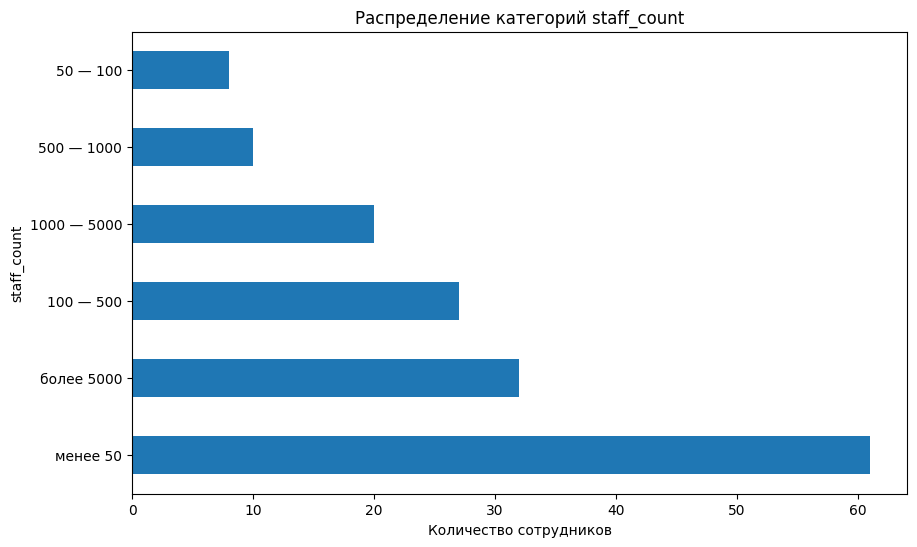

In [17]:
plt.figure(figsize=(10, 6))
staff_counts.plot(kind='barh')
plt.xlabel('Количество сотрудников')
plt.title('Распределение категорий staff_count')
plt.show()

In [18]:
vac_counts = company_df['vacancy_count'].value_counts()

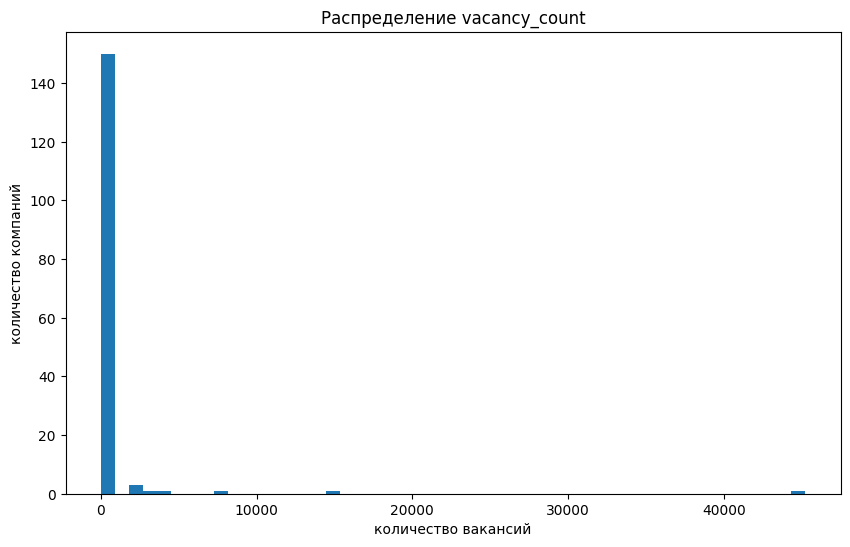

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(company_df['vacancy_count'], bins=50)
plt.xlabel('количество вакансий')
plt.ylabel('количество компаний')
plt.title('Распределение vacancy_count')
plt.show()

In [20]:
company_df[company_df['vacancy_count'] > 100]

,company_name,company_description,staff_count,vacancy_count
24224,ПСМ,"Корпорация, целью которой является оптимизация...",менее 50,452.0
24856,ГК Русагро,Группа Компаний «РУСАГРО» - это крупнейший вер...,1000 — 5000,8136.0
24992,Ростелеком,<p>ПАО «Ростелеком» — крупнейший в России инте...,более 5000,14534.0
25099,ФГБОУ ВО Санкт-Петербургский государственный у...,Санкт-Петербургский государственный университе...,более 5000,158.0
25576,Таттелеком,ПАО «Таттелеком» - один из ключевых операторов...,более 5000,126.0
25897,Билайн,<div>Билайн — это современный и открытый работ...,более 5000,444.0
26337,JOBCART.RU,Вакансии от прямых работодателей. В вакансии у...,менее 50,227.0
26819,ЦЕМРОС,"«ЦЕМРОС» — промышленный холдинг, лидер отечест...",более 5000,267.0
26920,Черногорская ГРК,Основанная в 2021 году ООО «Черногорская ГРК» ...,500 — 1000,2238.0
27281,Мечел,«Мечел» – глобальная горнодобывающая и металлу...,более 5000,255.0


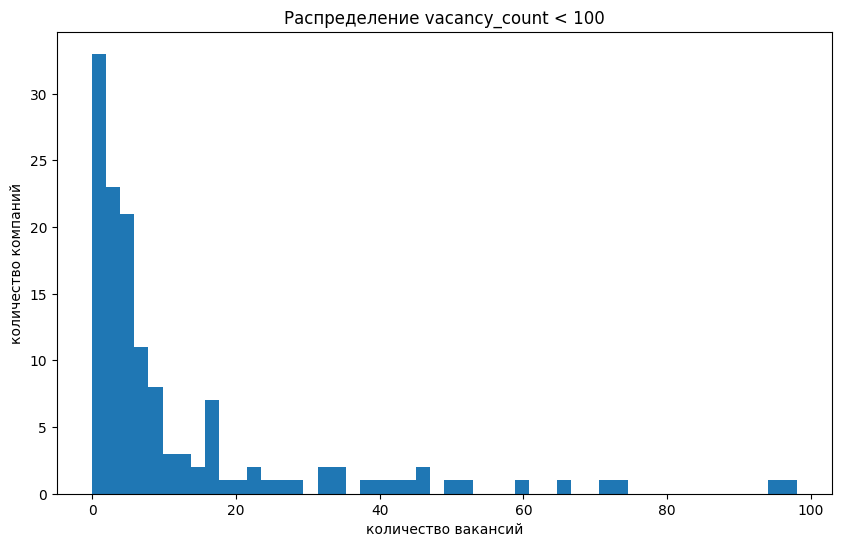

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(company_df[company_df['vacancy_count'] < 100]['vacancy_count'], bins=50)
plt.xlabel('количество вакансий')
plt.ylabel('количество компаний')
plt.title('Распределение vacancy_count < 100')
plt.show()

Выводы:
- в основном в наших выборках либо крупные компании(больше 5000 сотрудников), либо совмем малые организации(меньше 50 сотрудников)
- в огромных компаниях очень много вакансий
- в маленьких, скорее до 20

### Работа с целевой переменной - ЗП

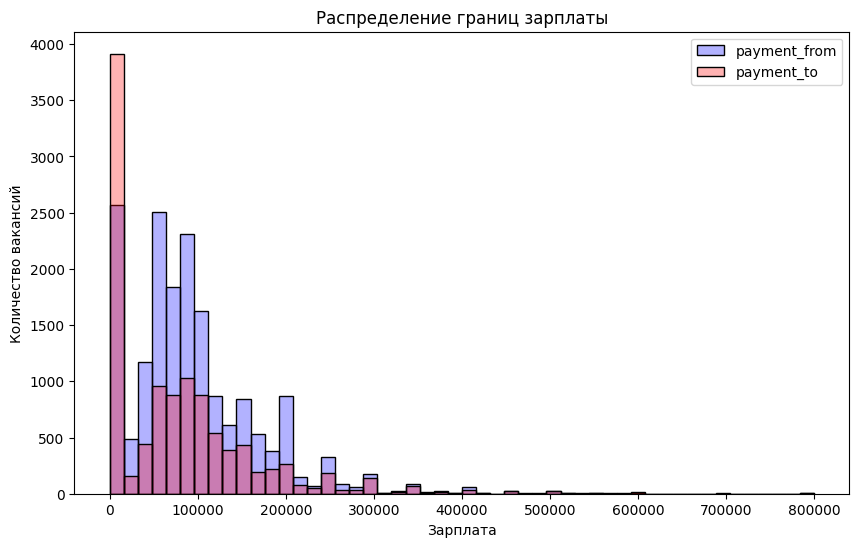

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df['payment_from'].dropna(), bins=50, color='blue', alpha=0.3, label='payment_from')
sns.histplot(df['payment_to'].dropna(), bins=50, color='red', alpha=0.3, label='payment_to')
plt.xlabel('Зарплата')
plt.ylabel('Количество вакансий')
plt.title('Распределение границ зарплаты')
plt.legend()
plt.show()

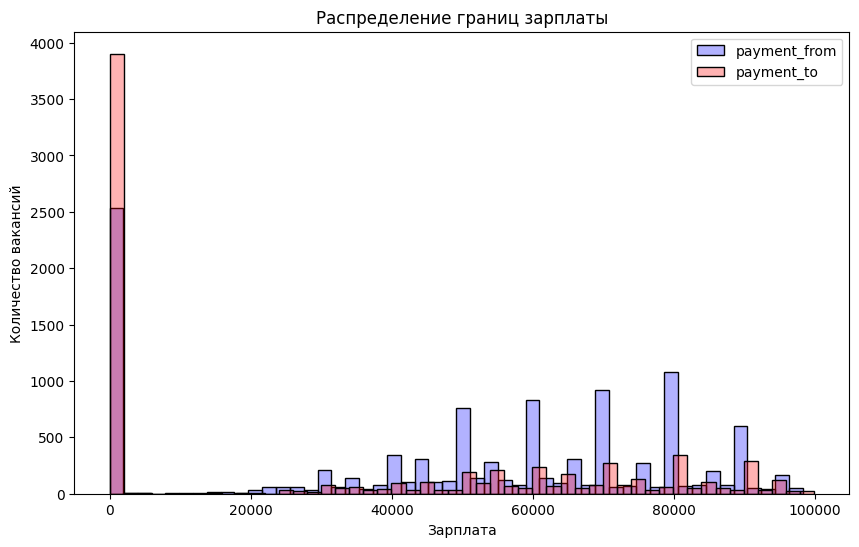

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['payment_from'] < 100000]['payment_from'].dropna(), bins=50, color='blue', alpha=0.3, label='payment_from')
sns.histplot(df[df['payment_to'] < 100000]['payment_to'].dropna(), bins=50, color='red', alpha=0.3, label='payment_to')
plt.xlabel('Зарплата')
plt.ylabel('Количество вакансий')
plt.title('Распределение границ зарплаты')
plt.legend()
plt.show()

На данных видно, что есть странный пик в нуле. С точки зрения логики, будем считать, что 0 = null, так как не может быть зп в 0 рублей(мы тут исключаем благотворительность и т д).

Также хочется проверить аномалии, могут быть кейсы, когда payment_to < payment_from. Мы экспертно обработаем дальше эти кейсы. Мы посмотрели на страницы, которые скрейпили и заметили некоторые паттерны. Их и обработаем далее

In [24]:
df[(df['payment_to'] < df['payment_from']) & (df['payment_to'] != 0) & (df['payment_from'] != 0)]

,profession,profession_full,vacancy_description,date_published,payment_from,payment_to,experience,employment,city,company_name,...,catalogues,source,dms,ai,work_format,education,1с,vacancy_description_tokenize,profession_raw,vacancy_category
100,Технолог,Технолог центра технологических компетенций( У...,"Компания ""Удмуртнефть имени В.И. Кудинова"" ПАО...",2026-03-25,63.0,12.0,NaN,Полная занятость,Воткинск,Удмуртнефть имени В.И. Кудинова,...,NaN,scrapping,1,0,2,1,0,компания удмуртнефть имя в.и. кудинов пао удму...,Технолог Технолог центра технологических компе...,инженер
329,Инженер технолог,Инженер технолог хранения сырья (сахарная свекла),"Компания ""Группа Компаний РУСАГРО"" Мы стреми...",2026-03-26,47000.0,61.0,NaN,Полная занятость,Знаменка (Тамбовская область),Группа Компаний РУСАГРО,...,NaN,scrapping,1,0,0,0,0,компания группа компания русагро жизнь человек...,Инженер технолог Инженер технолог хранения сыр...,инженер
368,Менеджер по работе с клиентами,Менеджер по работе с клиентами / Аккаунт-менед...,"Компания ""Digital Partners Global"" Привет!Мы -...",2026-03-25,138000.0,172.0,NaN,Полная занятость,Москва,Digital Partners Global,...,NaN,scrapping,0,0,0,0,0,компания привет!мы компания веб - приложение д...,Менеджер по работе с клиентами Менеджер по раб...,smm
1219,Помощник руководителя,Помощник руководителя / администратор 1С11,"Компания ""Авто-Альянс"" Обязанности: Администр...",2026-03-25,80000.0,149.0,NaN,Полная занятость,Тверь,Авто-Альянс,...,NaN,scrapping,0,0,0,0,1,компания авто - альянс обязанность администрир...,Помощник руководителя Помощник руководителя / ...,1с
1433,Разработчик,Flutter разработчик (Middle / Senior),"Компания ""Сммикод"" Разрабатываем мобильное при...",2026-03-26,70000.0,127.0,NaN,Полная занятость,Краснодар,Сммикод,...,NaN,scrapping,0,0,0,0,0,компания сммикод приложение управление система...,Разработчик Flutter разработчик (Middle / Senior),программист
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22771,Слесарь кипиа,"Наладчик КИПиА( РУСАЛ, Центр подбора персонала )","Компания ""РУСАЛ, Центр подбора персонала"" ОК Р...",2026-03-27,89.0,35.0,NaN,Полная занятость,Дмитров,"РУСАЛ, Центр подбора персонала",...,NaN,scrapping,0,0,0,1,0,компания русал центр подбор персонал ок русал ...,"Слесарь кипиа Наладчик КИПиА( РУСАЛ, Центр под...",инженер
23583,Python разработчик,Python-разработчик( Хазиев Карим Рашитович ),"Компания ""Хазиев Карим Рашитович"" Обязанности:...",2026-03-25,40000.0,1000.0,NaN,Полная занятость,Казань,Хазиев Карим Рашитович,...,NaN,scrapping,0,0,2,0,0,компания хазиев карим рашитович обязанность ан...,Python разработчик Python-разработчик( Хазиев ...,программист
23642,Программист,Программист в 1С,"Компания ""ЭВМ-Информ"" Обязанности: Разработка...",2026-03-28,1000.0,2.0,NaN,Частичная занятость,Астрахань,ЭВМ-Информ,...,NaN,scrapping,0,0,0,0,1,компания эвм - информ обязанность разработка т...,Программист Программист в 1С,1с
23717,Сервисный инженер,Сервисный инженер (холодильное и вентиляционно...,"Компания ""ТехноГрупп"" ТЕХНОГРУПП — ведущий рос...",2026-03-28,108000.0,140.0,NaN,Полная занятость,Люберцы,ТехноГрупп,...,NaN,scrapping,1,0,0,2,0,компания техногрупп техногрупп производитель п...,Сервисный инженер Сервисный инженер (холодильн...,инженер


In [25]:
df['payment_from_clean'] = df['payment_from']
df['payment_to_clean'] = df['payment_to']

# если payment_to меньше 1000 & payment_from > 1000, то payment_to * 1000
mask = (df['payment_to'] < 1000) & (df['payment_from'] > 1000)
df.loc[mask, 'payment_to_clean'] = df.loc[mask, 'payment_to'] * 1000

# если оба < 1000, то payment_from * 1000 + payment_to & payment_to = null
mask = (df['payment_from'] < 1000) & (df['payment_to'] < 1000)
df.loc[mask, 'payment_from_clean'] = df.loc[mask, 'payment_from'] * 1000
df.loc[mask, 'payment_to_clean'] = np.nan

# 0 = null
df.loc[df['payment_from_clean'] < 10, 'payment_from_clean'] = np.nan
df.loc[df['payment_to_clean'] < 10, 'payment_to_clean'] = np.nan

In [26]:
df[(df['payment_to'] < df['payment_from']) & (df['payment_to'] != 0) & (df['payment_from'] != 0)]

,profession,profession_full,vacancy_description,date_published,payment_from,payment_to,experience,employment,city,company_name,...,dms,ai,work_format,education,1с,vacancy_description_tokenize,profession_raw,vacancy_category,payment_from_clean,payment_to_clean
100,Технолог,Технолог центра технологических компетенций( У...,"Компания ""Удмуртнефть имени В.И. Кудинова"" ПАО...",2026-03-25,63.0,12.0,NaN,Полная занятость,Воткинск,Удмуртнефть имени В.И. Кудинова,...,1,0,2,1,0,компания удмуртнефть имя в.и. кудинов пао удму...,Технолог Технолог центра технологических компе...,инженер,63000.0,NaN
329,Инженер технолог,Инженер технолог хранения сырья (сахарная свекла),"Компания ""Группа Компаний РУСАГРО"" Мы стреми...",2026-03-26,47000.0,61.0,NaN,Полная занятость,Знаменка (Тамбовская область),Группа Компаний РУСАГРО,...,1,0,0,0,0,компания группа компания русагро жизнь человек...,Инженер технолог Инженер технолог хранения сыр...,инженер,47000.0,61000.0
368,Менеджер по работе с клиентами,Менеджер по работе с клиентами / Аккаунт-менед...,"Компания ""Digital Partners Global"" Привет!Мы -...",2026-03-25,138000.0,172.0,NaN,Полная занятость,Москва,Digital Partners Global,...,0,0,0,0,0,компания привет!мы компания веб - приложение д...,Менеджер по работе с клиентами Менеджер по раб...,smm,138000.0,172000.0
1219,Помощник руководителя,Помощник руководителя / администратор 1С11,"Компания ""Авто-Альянс"" Обязанности: Администр...",2026-03-25,80000.0,149.0,NaN,Полная занятость,Тверь,Авто-Альянс,...,0,0,0,0,1,компания авто - альянс обязанность администрир...,Помощник руководителя Помощник руководителя / ...,1с,80000.0,149000.0
1433,Разработчик,Flutter разработчик (Middle / Senior),"Компания ""Сммикод"" Разрабатываем мобильное при...",2026-03-26,70000.0,127.0,NaN,Полная занятость,Краснодар,Сммикод,...,0,0,0,0,0,компания сммикод приложение управление система...,Разработчик Flutter разработчик (Middle / Senior),программист,70000.0,127000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22771,Слесарь кипиа,"Наладчик КИПиА( РУСАЛ, Центр подбора персонала )","Компания ""РУСАЛ, Центр подбора персонала"" ОК Р...",2026-03-27,89.0,35.0,NaN,Полная занятость,Дмитров,"РУСАЛ, Центр подбора персонала",...,0,0,0,1,0,компания русал центр подбор персонал ок русал ...,"Слесарь кипиа Наладчик КИПиА( РУСАЛ, Центр под...",инженер,89000.0,NaN
23583,Python разработчик,Python-разработчик( Хазиев Карим Рашитович ),"Компания ""Хазиев Карим Рашитович"" Обязанности:...",2026-03-25,40000.0,1000.0,NaN,Полная занятость,Казань,Хазиев Карим Рашитович,...,0,0,2,0,0,компания хазиев карим рашитович обязанность ан...,Python разработчик Python-разработчик( Хазиев ...,программист,40000.0,1000.0
23642,Программист,Программист в 1С,"Компания ""ЭВМ-Информ"" Обязанности: Разработка...",2026-03-28,1000.0,2.0,NaN,Частичная занятость,Астрахань,ЭВМ-Информ,...,0,0,0,0,1,компания эвм - информ обязанность разработка т...,Программист Программист в 1С,1с,1000.0,NaN
23717,Сервисный инженер,Сервисный инженер (холодильное и вентиляционно...,"Компания ""ТехноГрупп"" ТЕХНОГРУПП — ведущий рос...",2026-03-28,108000.0,140.0,NaN,Полная занятость,Люберцы,ТехноГрупп,...,1,0,0,2,0,компания техногрупп техногрупп производитель п...,Сервисный инженер Сервисный инженер (холодильн...,инженер,108000.0,140000.0


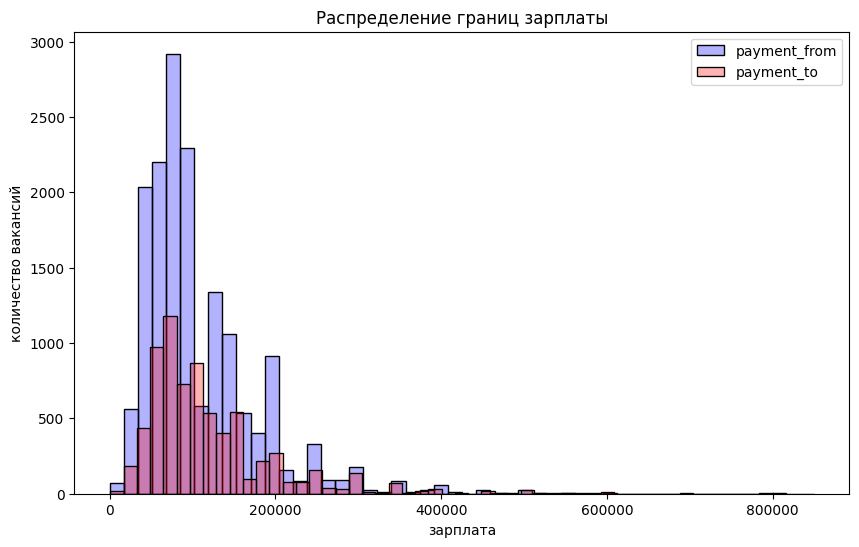

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df['payment_from_clean'].dropna(), bins=50, color='blue', alpha=0.3, label='payment_from')
sns.histplot(df['payment_to_clean'].dropna(), bins=50, color='red', alpha=0.3, label='payment_to')
plt.xlabel('зарплата')
plt.ylabel('количество вакансий')
plt.title('Распределение границ зарплаты')
plt.legend()
plt.show()

/tmp/ipykernel_35313/2455197277.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


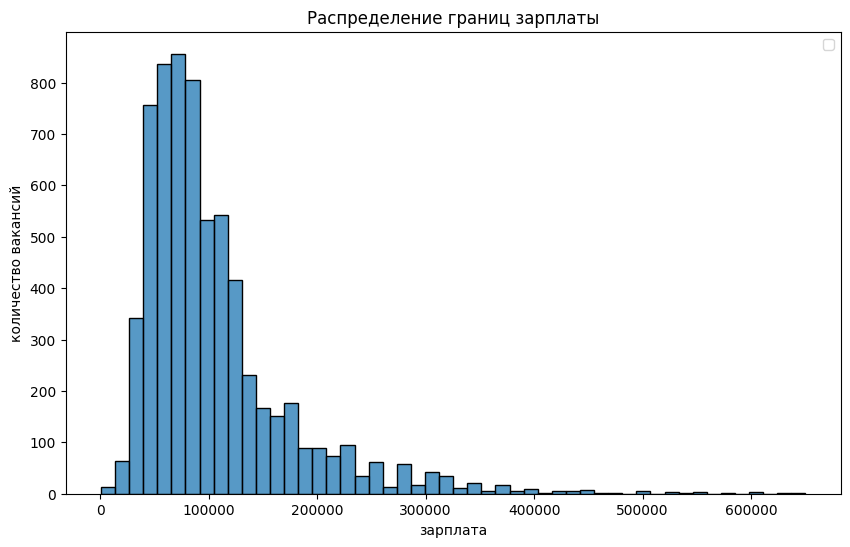

In [28]:
df['payment_avg'] = np.where(
    (df['payment_from_clean'] > 0) & (df['payment_to_clean'] > 0),
    (df['payment_from_clean'] + df['payment_to_clean']) / 2,
    np.nan
)
plt.figure(figsize=(10, 6))
sns.histplot(df['payment_avg'].dropna(), bins=50)
plt.xlabel('зарплата')
plt.ylabel('количество вакансий')
plt.title('Распределение границ зарплаты')
plt.legend()
plt.show()

Подведем тут итог:
- мы обработали неидельность собра данных целевой переменной
- получили реалистичное распределение ЗП: большая часть вакансий в районе 100000 рублей, есть хвост справа, вплоть до 600000 рублей

### Посмотрим отдельно на самые популярные профессии

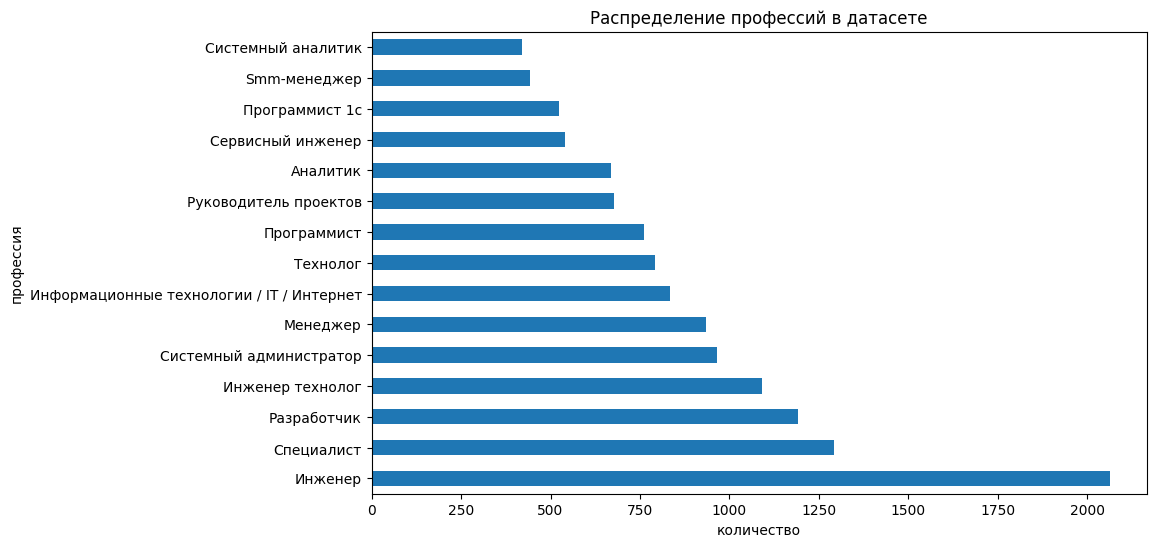

In [29]:
pr_counts = df['profession'].value_counts()[:15]
plt.figure(figsize=(10, 6))
pr_counts.plot(kind='barh')
plt.xlabel('количество')
plt.ylabel('профессия')
plt.title('Распределение профессий в датасете')
plt.show()

In [30]:
top_professions = df[~df['payment_avg'].isna()]['profession'].value_counts()[:15].index
df_top = df[df['profession'].isin(top_professions)]
df_top

,profession,profession_full,vacancy_description,date_published,payment_from,payment_to,experience,employment,city,company_name,...,ai,work_format,education,1с,vacancy_description_tokenize,profession_raw,vacancy_category,payment_from_clean,payment_to_clean,payment_avg
2,Специалист,Middle+ AQA специалист,"Компания ""Компания Ритейл Сервис"" Мы - аккреди...",2026-03-26,140000.0,180000.0,NaN,Полная занятость,Барнаул,Компания Ритейл Сервис,...,0,2,0,0,компания компания - ит - компания по artix- ре...,Специалист Middle+ AQA специалист,qa,140000.0,180000.0,160000.0
3,Технолог,Технолог( АКРИХИН ),"Компания ""АКРИХИН"" Обязанности: Обеспечивать ...",2026-03-25,NaN,NaN,NaN,Полная занятость,Старая Купавна,АКРИХИН,...,0,0,2,0,компания акрихин обязанность соблюдение персон...,Технолог Технолог( АКРИХИН ),инженер,NaN,NaN,NaN
5,Инженер технолог,"Инженер-технолог ЖБИ( Алабуга, ОЭЗ ППТ )","Компания ""Алабуга, ОЭЗ ППТ"" Обязанности: разр...",2026-03-26,450000.0,NaN,Более 6 лет,Полная занятость,Набережные Челны,"Алабуга, ОЭЗ ППТ",...,0,0,0,0,компания алабуга оэз ппт обязанность разработк...,Инженер технолог Инженер-технолог ЖБИ( Алабуга...,инженер,450000.0,NaN,NaN
6,Инженер,Инженер по наладке и испытаниям/Специализирова...,"Компания ""Норникель"" В Заполярный филиал ПАО ""...",2026-03-28,350000.0,NaN,NaN,Полная занятость,Котельниково,Норникель,...,0,0,1,0,компания норникель филиал пао гмк никель предп...,Инженер Инженер по наладке и испытаниям/Специа...,инженер,350000.0,NaN,NaN
9,Инженер,Инженер внедрения голосовых решений,"Компания ""Цитадель"" Компании, работающие под б...",2026-03-27,NaN,NaN,NaN,Полная занятость,Хабаровск,Цитадель,...,0,0,0,0,компания цитадель компания бренд цитадель it -...,Инженер Инженер внедрения голосовых решений,инженер,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30735,Системный администратор,Системный администратор,Завод ПЛАРУС - единственная в РФ компания полн...,2026-04-03,100000.0,125000.0,NaN,NaN,Солнечногорск,Завод по переработке пластмасс ПЛАРУС,...,0,0,2,0,завод пларус - компания цикл переработка б/у б...,Системный администратор Системный администратор,администратор,100000.0,125000.0,112500.0
30736,Системный администратор,Системный администратор,Завод ПЛАРУС - единственная в РФ компания полн...,2026-04-03,100000.0,120000.0,NaN,NaN,"{'id': 817, 'title': 'Клин', 'declension': 'в ...",Завод по переработке пластмасс ПЛАРУС,...,0,0,2,0,завод пларус - компания цикл переработка б/у б...,Системный администратор Системный администратор,администратор,100000.0,120000.0,110000.0
30737,Системный администратор,Системный администратор,Завод ПЛАРУС - единственная в РФ компания полн...,2026-04-03,100000.0,125000.0,NaN,NaN,"{'id': 852, 'title': 'Солнечногорск', 'declens...",Завод по переработке пластмасс ПЛАРУС,...,0,0,2,0,завод пларус - компания цикл переработка б/у б...,Системный администратор Системный администратор,администратор,100000.0,125000.0,112500.0
30847,Инженер,Инженер,Обязанности:\n• Уметь работать с технической д...,2026-04-05,60000.0,70000.0,NaN,NaN,"{'id': 4, 'title': 'Москва', 'declension': 'в ...",Академия управления МВД России,...,0,0,0,0,обязанность документация документ бюро докумен...,Инженер Инженер,инженер,60000.0,70000.0,65000.0


In [32]:
prof_fd = df_top.groupby('profession').agg(
    count=('profession', 'count'),
    avg_salary=('payment_avg', 'mean')
).reset_index()

prof_fd = prof_fd.sort_values('avg_salary', ascending=True)

fig = px.bar(prof_fd,
             y='profession',
             x='count',
             color='avg_salary',
             orientation='h',
             title='Топ профессий по популярности',
             color_continuous_scale='blues',
             text='count')
fig.show()

#### Заберу теперь разметку свои коллег, посмотрим на распределение там

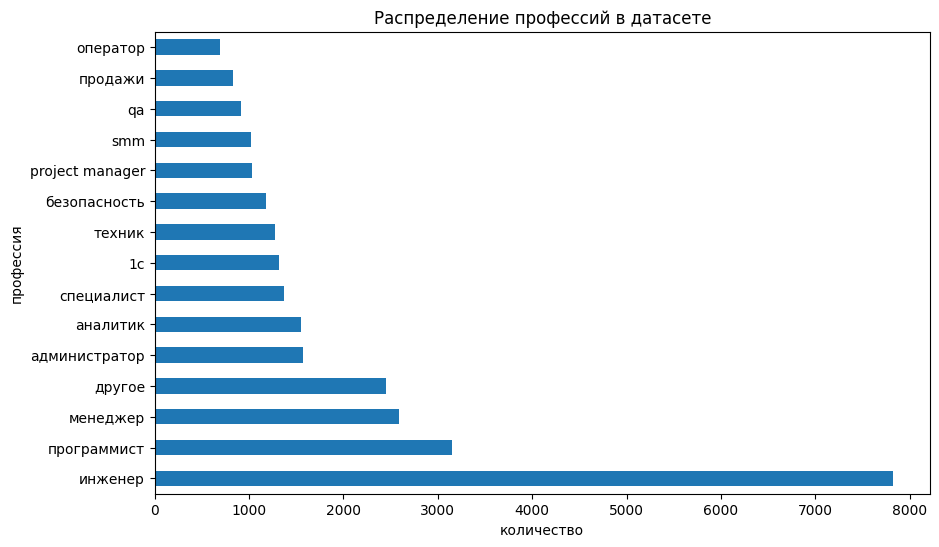

In [33]:
pr_counts = df['vacancy_category'].value_counts()[:15]
plt.figure(figsize=(10, 6))
pr_counts.plot(kind='barh')
plt.xlabel('количество')
plt.ylabel('профессия')
plt.title('Распределение профессий в датасете')
plt.show()

In [70]:
top_professions = df[~df['payment_avg'].isna()]['vacancy_category'].value_counts().head(15).index
df_top = df[df['vacancy_category'].isin(top_professions)]

prof_stats = df_top.groupby('vacancy_category').agg(
    count=('vacancy_category', 'count'),
    avg_salary=('payment_avg', 'mean')
).reset_index()

prof_stats = prof_stats.sort_values('avg_salary', ascending=True)

fig = px.bar(prof_stats,
             y='vacancy_category',
             x='count',
             color='avg_salary',
             orientation='h',
             title='Топ профессий по популярности',
             color_continuous_scale='blues',
             text='count')
fig.show()

Давайте проверим на статзначимость, что программисты получают больше, чем инженеры

H0: зарплаты инженеров и программистов не отличаются

H1: зарплаты программистов больше, чем у инженеров

In [35]:
p = df[(df['vacancy_category'] == 'программист')]['payment_avg'].dropna()
i = df[(df['vacancy_category'] == 'инженер')]['payment_avg'].dropna()

In [36]:
p.shape, i.shape # больше 30

((380,), (1225,))

In [37]:
stats.ttest_ind(p, i, equal_var=False, alternative='greater')

TtestResult(statistic=np.float64(11.644508676130952), pvalue=np.float64(4.583120612740757e-28), df=np.float64(478.6440252447549))

Да, различия статзначимы на уровне 5%

Посмотрим на влияние образования на уровень зп

In [57]:
netreb = df[df['education']==0]
sr = df[df['education']==1]
v = df[df['education']==2]

In [58]:
netrebs = netreb['payment_avg']
srs = sr['payment_avg']
vss = v['payment_avg']

In [59]:
netrebs = netrebs.dropna()
srs = srs.dropna()
vss = vss.dropna()

In [62]:
print(netrebs.shape[0])
print(srs.shape[0])
print(vss.shape[0])

4432
690
1482


больше 30 наблюдений, используем т-тест с поправкой Бонферрони

H0 - Уровень образования не влияет на уровень зп

H1 - Уровень образования влияет на зп

In [64]:
q = 0.05/3

In [65]:
q

0.016666666666666666

Наш уровень значимости (поправка Бонферрони)

In [66]:
from scipy import stats

In [67]:
zn, pv = stats.ttest_ind(netrebs, srs)
print(zn, pv)

3.4660810378473896 0.0005324414340174433


In [68]:
zn, pv = stats.ttest_ind(netrebs, vss)
print(zn, pv)

-9.61740302572784 9.732971989459252e-22


In [69]:
zn, pv = stats.ttest_ind(srs, vss)
print(zn, pv)

-10.47425291792512 4.446866075456564e-25


Все p-value < нашего уровня значимость = 0,17, поэтому отвергаем нулевую гипотезу о том, что уровень образования не влияет на уровень зп

# Признак Город

Кажется, ни для кого не секрет, что в зависимости от города зарплаты различаются. Проверим это на наших данных.

Для начала выведем топ-15 городов по средней зп

In [38]:
df['city'].value_counts()

,count
city,
Москва,10205
Санкт-Петербург,3043
Екатеринбург,816
Новосибирск,604
Казань,590
...,...
"{'id': 2149, 'title': 'Полысаево', 'declension': 'в Полысаеве', 'hasMetro': False, 'genitive': 'Полысаева'}",1
"{'id': 2246, 'title': 'Салаир', 'declension': 'в Салаире', 'hasMetro': False, 'genitive': 'Салаира'}",1
"{'id': 2014, 'title': 'Тайга', 'declension': 'в Тайге', 'hasMetro': False, 'genitive': 'Тайги'}",1


In [39]:
import ast # https://habr.com/ru/companies/piter/articles/493424/

def extract_city_name(city_value):
    if pd.isna(city_value):
        return np.nan
    if str(city_value).startswith('{'):
          city_dict = ast.literal_eval(city_value)
          return city_dict.get('title', np.nan)
    else:
          return city_value

df['city_name'] = df['city'].apply(extract_city_name)

In [40]:
df['city_name'].value_counts()

,count
city_name,
Москва,10354
Санкт-Петербург,3109
Екатеринбург,820
Новосибирск,608
Казань,606
...,...
Большая Мартыновка,1
Лабытнанги,1
Вышний Волочек,1


In [41]:
city_avg_salary = df.groupby('city_name')['payment_avg'].mean().sort_values(ascending=False).head(15).reset_index()
city_avg_salary.columns = ['city_name', 'avg_salary']
city_avg_salary

,city_name,avg_salary
0,Змеиногорск,363500.000000
1,Билибино,220000.000000
2,Магадан,203409.090909
3,Мариуполь,200000.000000
4,Белоусово,200000.000000
5,Иннополис,198750.000000
6,Болохово,195000.000000
7,Краснозаводск,190000.000000
8,Благовещенск,184750.000000
9,Нижневартовск,183916.666667


Отсюда видим следующее - в маленьких и удаленных городах(вы вот слышали о Змеиногорске?) мало вакансий, но высокое среднее.

Но давайте проверим статистически:

Н0 : В Москве и Питере ЗП не отличается от других городов

H1 : В Москве и Питере ЗП выше, чем в других городах


In [42]:
big = df[(df['city_name'] == 'Москва') | (df['city_name'] == 'Санкт-Петербург')]['payment_avg'].dropna()
small = df[(df['city_name'] != 'Москва') & (df['city_name'] != 'Санкт-Петербург')]['payment_avg'].dropna()

In [43]:
big.shape, small.shape # больше 30

((2074,), (4530,))

In [44]:
stats.ttest_ind(big, small, equal_var=False, alternative='greater')

TtestResult(statistic=np.float64(24.667411267909028), pvalue=np.float64(8.438910989798907e-122), df=np.float64(2740.4871621016573))

Да, есть стат разница. Наши любимые столицы мира готовы платить больше

### Посмотрим на даты размещения вакансий


In [45]:
daily_salary_stats = df.groupby('date_published').agg(
    salary_count=('payment_avg', 'count'),
    avg_salary=('payment_avg', 'mean')
).reset_index()
daily_salary_stats

,date_published,salary_count,avg_salary
0,2025-12-20,0,NaN
1,2026-01-04,0,NaN
2,2026-01-06,0,NaN
3,2026-01-14,0,NaN
4,2026-01-19,0,NaN
5,2026-01-25,0,NaN
6,2026-03-01,0,NaN
7,2026-03-02,1,120000.000000
8,2026-03-03,1,140000.000000
9,2026-03-18,0,NaN


In [46]:
daily_salary_stats['date_published'] = pd.to_datetime(daily_salary_stats['date_published'])
daily_salary_stats = daily_salary_stats.sort_values('date_published')
fig = px.line(daily_salary_stats,
              x='date_published',
              y='salary_count',
              title='Количество вакансий по дням',
              markers=True)

fig.show()

In [47]:
daily_salary_stats = df[df['date_published'] >= '2026-03-01'].groupby('date_published').agg(
    salary_count=('payment_avg', 'count'),
    avg_salary=('payment_avg', 'mean')
).reset_index()
daily_salary_stats

,date_published,salary_count,avg_salary
0,2026-03-01,0,NaN
1,2026-03-02,1,120000.000000
2,2026-03-03,1,140000.000000
3,2026-03-18,0,NaN
4,2026-03-20,0,NaN
5,2026-03-21,0,NaN
6,2026-03-22,3,178333.333333
7,2026-03-23,4,137500.000000
8,2026-03-25,779,134635.430039
9,2026-03-26,783,129259.897829


In [48]:
daily_salary_stats['date_published'] = pd.to_datetime(daily_salary_stats['date_published'])
daily_salary_stats = daily_salary_stats.sort_values('date_published')
fig = px.line(daily_salary_stats,
              x='date_published',
              y='salary_count',
              title='Количество вакансий с указанной зарплатой по дням',
              markers=True)
fig.show()

Можем сделать вывод, что на момент парсинга, вакансии размещенные в начале марта уже были неактуальны

### Инстересная тема с бенефитами
Го проверим, что ваки с ДМС отличаются по деньгам от вак без ДМС.

Н0 : ваки с ДМС не отличаются по деньгам от вак без ДМС

H1 : ваки с ДМС предлагают больше по деньгам от вак без ДМС

In [49]:
with_benefits = df[df['dms'] == 1]['payment_avg'].dropna()
no_benefits = df[df['dms'] == 0]['payment_avg'].dropna()

In [50]:
with_benefits.shape, no_benefits.shape # больше 30

((1959,), (4645,))

In [51]:
stats.ttest_ind(with_benefits, no_benefits, equal_var=False, alternative='greater')

TtestResult(statistic=np.float64(1.759149101680063), pvalue=np.float64(0.03932268089818567), df=np.float64(3281.819921082905))

Статзначимость на уровне 5% есть. Можем предположить, что это априори более крупные компании, которые кроме более высокой зп могут дать бонусом и бенефиты. А компании без ДМС, скорее всего маленькие, и им мало выгодно привлекать сотрудников соц пакетом

### Давайте сравним ЗП из разных испочников

Н0 : зарплаты на Карьеристе и Superjob не отличаются

H1 : зарплаты на Карьеристе и Superjob отличаются

In [52]:
c = df[df['source'] != 'scrapping']['payment_avg'].dropna()
k = df[df['source'] == 'scrapping']['payment_avg'].dropna()

In [53]:
c.shape, k.shape # больше 30

((3196,), (3408,))

In [54]:
stats.ttest_ind(c, k, equal_var=False, alternative='less')

TtestResult(statistic=np.float64(-34.89830481350294), pvalue=np.float64(5.733485044348566e-240), df=np.float64(5141.301977773188))

На уровне значимости 5% можем сказать, что на Карьеристе ЗП выше. Но тут важна оговорка, что это возможно скамные вакансии, и что далеко не везде в целом указывают ЗП. Но на наших данных результаты такие


Давайте еще посмотрим на только те ЗП, где есть упоминание AI. Кажется, это сделает выборки более сравнимыми.

In [55]:
c = df[(df['source'] != 'scrapping') & (df['ai'] == 1)]['payment_avg'].dropna()
k = df[(df['source'] == 'scrapping') & (df['ai'] == 1)]['payment_avg'].dropna()

In [56]:
c.shape, k.shape

((5,), (226,))

В метче с коллегами подтверждаем на наших данных, что ai вероятно, повышает зп в вакансии